# Step Metrics Overview

This chart shows the evolution of the main training metrics over **global steps**:

- **Reward**: the agent’s performance signal during training.
- **Train loss**: optimization loss values recorded intermittently.
- **Actor loss**: policy update loss values.
- **Critic loss**: value-function update loss values.

## Interpretation

- The **reward** curve is tracked continuously across the full training run.
- The **loss metrics** are much sparser, indicating they are logged only at selected training updates.
- The use of **scientific notation** on both axes helps make large step counts and small loss values easier to read.
- Together, these plots provide a quick view of both **training stability** and **learning progress** over time.

In [1]:
import os
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


def _set_publication_style(base_font_size: int = 9):
    """Set matplotlib parameters for publication-quality figures."""
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif", "STIXGeneral"],
        "mathtext.fontset": "stix",
        "font.size": base_font_size,
        "axes.labelsize": base_font_size,
        "axes.titlesize": base_font_size + 1,
        "legend.fontsize": base_font_size - 1,
        "xtick.labelsize": base_font_size - 1,
        "ytick.labelsize": base_font_size - 1,
        "axes.linewidth": 0.9,
        "lines.linewidth": 1.8,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
    })


def _load_train_loss_series(
    experiment_folders: dict,
    metrics_rel_path: str = os.path.join("metrics", "step_metrics.csv"),
    x_col: str = "global_step",
    y_col: str = "train_loss",
):
    loaded = {}

    for name, folder in experiment_folders.items():
        csv_path = os.path.join(folder, metrics_rel_path)
        if not os.path.exists(csv_path):
            print(f"[WARN] Missing file for {name}: {csv_path}")
            continue

        df = pd.read_csv(csv_path)
        if y_col not in df.columns:
            print(f"[WARN] '{y_col}' not found in {name}")
            continue

        y = pd.to_numeric(df[y_col], errors="coerce")
        mask = y.notna()

        if not mask.any():
            print(f"[WARN] No valid '{y_col}' values in {name}")
            continue

        if x_col in df.columns:
            x = pd.to_numeric(df[x_col], errors="coerce")
        else:
            x = pd.Series(range(len(df)))

        x = x[mask].reset_index(drop=True)
        y = y[mask].reset_index(drop=True)

        loaded[name] = {"x": x, "y": y}

    return loaded


def _smooth_series(y: pd.Series, window: int):
    if window is None or window <= 1 or len(y) < window:
        return y
    return y.rolling(window=window, min_periods=1, center=True).mean()


def _print_summary(loaded: dict, title: str):
    if not loaded:
        print(f"\n{title}: No data loaded.")
        return None

    summary_rows = []
    for name, d in loaded.items():
        summary_rows.append(
            {
                "experiment": name,
                "n_points": len(d["y"]),
                "mean_train_loss": d["y"].mean(),
                "median_train_loss": d["y"].median(),
                "min_train_loss": d["y"].min(),
                "last_train_loss": d["y"].iloc[-1],
            }
        )

    summary_df = pd.DataFrame(summary_rows).sort_values("mean_train_loss")
    print(f"\n{title} (lower is better):")
    print(summary_df.to_string(index=False))
    return summary_df


def compare_train_loss_split(
    experiment_folders_left: dict,
    experiment_folders_right: dict,
    metrics_rel_path: str = os.path.join("metrics", "step_metrics.csv"),
    x_col: str = "global_step",
    y_col: str = "train_loss",
    max_points: int = None,
    smooth_window: int = 25,
    figure_size=(3.6, 2.5),
    title: str = "Train Loss",
    xlabel: str = "Training step",
    ylabel: str = "Train loss",
    base_font_size: int = 9,
    save_path: str = None,
    dpi: int = 600,
):
    """
    Publication-ready train-loss plot.

    - Left group uses solid lines.
    - Right group uses dashed lines.
    - Designed for paper columns; default size works well in two-column layouts.
    """
    _set_publication_style(base_font_size=base_font_size)

    left_loaded = _load_train_loss_series(experiment_folders_left, metrics_rel_path, x_col, y_col)
    right_loaded = _load_train_loss_series(experiment_folders_right, metrics_rel_path, x_col, y_col)

    fig, ax = plt.subplots(1, 1, figsize=figure_size)

    color_cycle = plt.get_cmap("tab10").colors
    marker_cycle = itertools.cycle(["o", "s", "^", "D", "v", "P", "X"])

    def _plot_group(group_loaded: dict, linestyle: str, group_prefix: str):
        for idx, (name, d) in enumerate(group_loaded.items()):
            x_plot = d["x"] if max_points is None else d["x"][:max_points]
            y_plot = d["y"] if max_points is None else d["y"][:max_points]
            y_plot = _smooth_series(y_plot, smooth_window)

            ax.plot(
                x_plot,
                y_plot,
                label=f"{group_prefix}{name}",
                linestyle=linestyle,
                color=color_cycle[idx % len(color_cycle)],
                marker=next(marker_cycle),
                markevery=max(1, len(x_plot) // 10),
                markersize=3.0,
                linewidth=1.9,
                alpha=0.95,
            )

    _plot_group(left_loaded, linestyle="-", group_prefix="")
    _plot_group(right_loaded, linestyle="--", group_prefix="")

    x_formatter = ScalarFormatter(useMathText=True)
    y_formatter = ScalarFormatter(useMathText=True)
    x_formatter.set_scientific(True)
    y_formatter.set_scientific(True)
    x_formatter.set_powerlimits((0, 0))
    y_formatter.set_powerlimits((0, 0))
    ax.xaxis.set_major_formatter(x_formatter)
    ax.yaxis.set_major_formatter(y_formatter)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if left_loaded or right_loaded:
        ax.legend(
            loc="best",
            frameon=False,
            ncol=1,
            handlelength=2.6,
            borderaxespad=0.3,
        )

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=dpi)
        print(f"[INFO] Figure saved to: {save_path}")

    plt.show()

    left_summary = _print_summary(left_loaded, "left summary")
    right_summary = _print_summary(right_loaded, "right summary")
    return left_summary, right_summary

[INFO] Figure saved to: C:\Users\es25591\Workspace\CacheVideoPredict360\Graphs\train_loss_publication.pdf


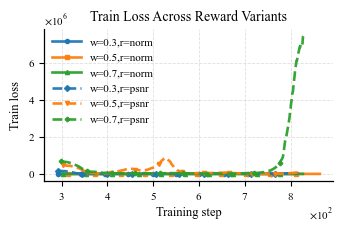


left summary (lower is better):
  experiment  n_points  mean_train_loss  median_train_loss  min_train_loss  last_train_loss
w=0.5,r=norm      1554       187.468498          32.404840      -10.726288        19.906204
w=0.7,r=norm      1646       539.747241         135.759552       -8.673832       445.888245
w=0.3,r=norm      1688       593.484402          48.972965       -2.800585       146.037048

right summary (lower is better):
  experiment  n_points  mean_train_loss  median_train_loss  min_train_loss  last_train_loss
w=0.7,r=psnr      1596     3.401741e+05       85929.292969     4529.130371     9.446442e+03
w=0.5,r=psnr      1678     1.018767e+06       23774.637695     3281.172363     4.377246e+03
w=0.3,r=psnr      1656     1.008130e+07      108026.113281     3802.958740     1.244829e+08


In [2]:
# --- Example usage (publication-ready export) ---
experiments = {
    "w=0.3,r=norm": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_11-32",
    "w=0.5,r=norm": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_11-48",
    "w=0.7,r=norm": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_12-03",
}

experiments_right = {
    "w=0.3,r=psnr": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_12-42",
    "w=0.5,r=psnr": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_12-28",
    "w=0.7,r=psnr": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_12-15",
}

left_summary, right_summary = compare_train_loss_split(
    experiments,
    experiments_right,
    x_col="global_step",
    y_col="train_loss",
    max_points=500,
    smooth_window=21,
    figure_size=(3.5, 2.4),
    title="Train Loss Across Reward Variants",
    xlabel="Training step",
    ylabel="Train loss",
    base_font_size=9,
    save_path=r"C:\Users\es25591\Workspace\CacheVideoPredict360\Graphs\train_loss_publication.pdf",
    dpi=600,
)

{'latest': 'c:\\Users\\es25591\\Workspace\\CacheVideoPredict360\\Results\\2026-05-05_13-11'}
[INFO] Figure saved to: C:\Users\es25591\Workspace\CacheVideoPredict360\Graphs\latest_train_loss.pdf


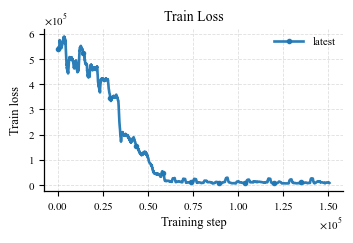


left summary (lower is better):
experiment  n_points  mean_train_loss  median_train_loss  min_train_loss  last_train_loss
    latest     57636     17855.719208        9522.429688      1569.05835      5335.084961

right summary: No data loaded.


In [4]:
# Note: The experiments are disconsidering the warmup phase

cur_path = r"c:\Users\es25591\Workspace\CacheVideoPredict360\Results"

# --- Example usage ---
cur_f = max(
    [d for d in os.listdir(cur_path) 
     if os.path.isdir(os.path.join(cur_path, d)) and len(d) == 16],
    key=lambda x: x
)


experiments = {
    "latest": os.path.join(cur_path, cur_f)
}

print(experiments)
experiments_right = {}

left_summary, right_summary = compare_train_loss_split(
    experiments,
    experiments_right,
    x_col="global_step",
    y_col="train_loss",
    max_points=2300,
    save_path=r"C:\Users\es25591\Workspace\CacheVideoPredict360\Graphs\latest_train_loss.pdf",
)